In [ ]:
%pip install pandas

In [ ]:
%pip install kagglehub

In [ ]:
%pip install matplotlib

In [ ]:
%pip install scikit-learn

In [42]:
%pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("CooperUnion/anime-recommendations-database")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/julieannsalangsang/.cache/kagglehub/datasets/CooperUnion/anime-recommendations-database/versions/1


In [5]:
import pandas as pd
df = pd.read_csv(f"{path}/anime.csv")

print(df.head())

print("\nDataset Information:" )
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print(df.describe())

print(df["episodes"].unique()[:30]) 

   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Cou

Data Cleaning

In [6]:
print(df.isnull().sum())

df["episodes"] = pd.to_numeric(df["episodes"], errors="coerce")

print(df["episodes"].dtype)
print(df["episodes"].isnull().sum())

# missing values
print(df.isnull().sum())

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64
float64
340
anime_id      0
name          0
genre        62
type         25
episodes    340
rating      230
members       0
dtype: int64


In [7]:
df = df.dropna(
    subset=["episodes", "rating", "type", "genre"]
)

df = df.reset_index(drop=True)

print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

(11830, 7)

Missing Values:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


Data Exploratory Analysis

In [8]:
print(df.describe())

print(df["rating"].describe())

           anime_id      episodes        rating       members
count  11830.000000  11830.000000  11830.000000  1.183000e+04
mean   13404.150211     12.486729      6.484609  1.851100e+04
std    11110.087616     47.097131      1.019147  5.537144e+04
min        1.000000      1.000000      1.670000  1.200000e+01
25%     3326.250000      1.000000      5.892500  2.322500e+02
50%     9820.500000      2.000000      6.570000  1.589500e+03
75%    23302.500000     12.000000      7.190000  9.832000e+03
max    34519.000000   1818.000000     10.000000  1.013917e+06
count    11830.000000
mean         6.484609
std          1.019147
min          1.670000
25%          5.892500
50%          6.570000
75%          7.190000
max         10.000000
Name: rating, dtype: float64


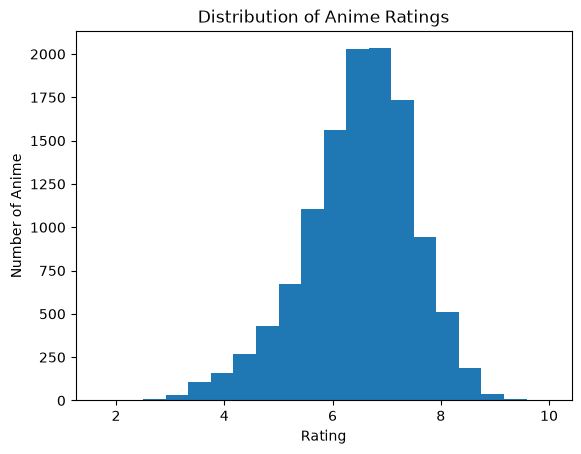

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["rating"], bins=20)
plt.xlabel("Rating")
plt.ylabel("Number of Anime")
plt.title("Distribution of Anime Ratings")
plt.show()

In [10]:
# average rating by anime type
type_rating = (
    df.groupby("type")["rating"]
    .mean()
    .sort_values(ascending=False)
)

print (type_rating)

type
TV         6.929487
Special    6.525453
OVA        6.371087
Movie      6.334486
ONA        5.640479
Music      5.588665
Name: rating, dtype: float64


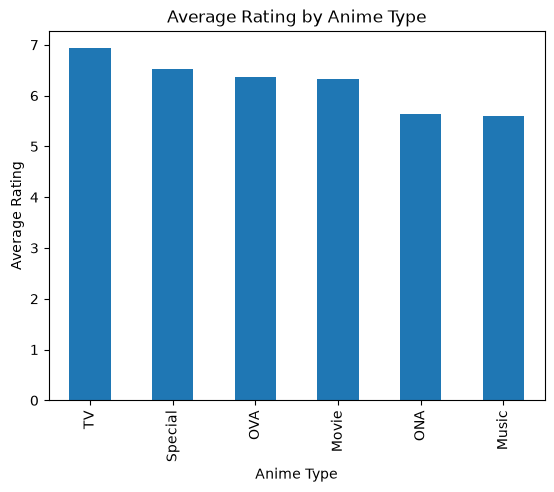

In [11]:
type_rating.plot(kind="bar")

plt.xlabel("Anime Type")
plt.ylabel("Average Rating")
plt.title("Average Rating by Anime Type")
plt.show()

In [12]:
# relationship between members and rating. 
# members represents populartiy, we wnat to know whether the more popular an anime is, the higher the rating

print(df[["members", "rating"]].corr())

          members    rating
members  1.000000  0.391027
rating   0.391027  1.000000


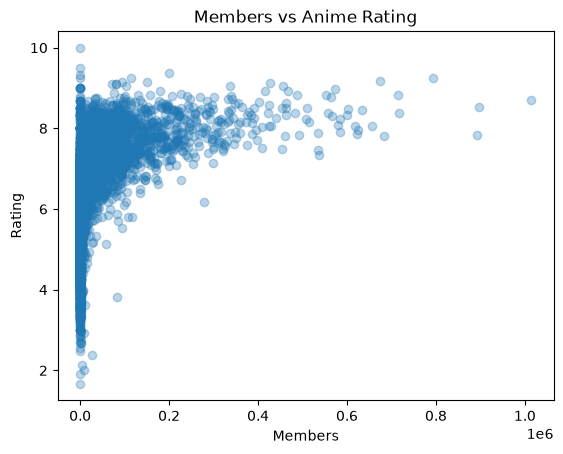

In [13]:
plt.scatter(df["members"], df["rating"], alpha=0.3)

plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("Members vs Anime Rating")
plt.show()

In [14]:
# relationship between episodes and rating

print(df[["episodes", "rating"]].corr())

          episodes   rating
episodes   1.00000  0.08819
rating     0.08819  1.00000


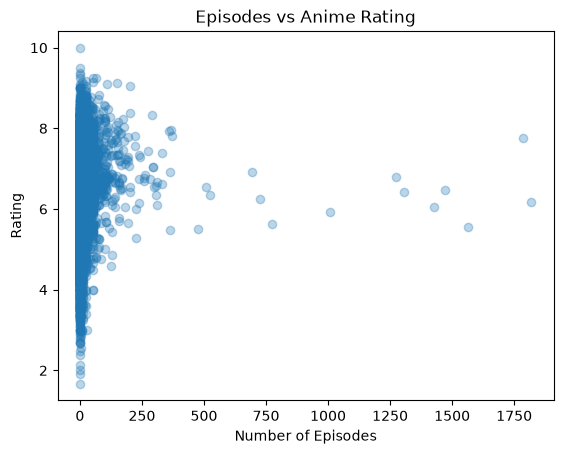

In [15]:
plt.scatter(df["episodes"], df["rating"], alpha=0.3)

plt.xlabel("Number of Episodes")
plt.ylabel("Rating")
plt.title("Episodes vs Anime Rating")
plt.show()

In [16]:
# getting the top rated anime

top_rated = (
    df[["name", "type", "episodes", "rating", "members"]]
    .sort_values(by="rating", ascending=False)
    .head(10)
)

print(top_rated)

                                                    name   type  episodes  \
10277            Taka no Tsume 8: Yoshida-kun no X-Files  Movie       1.0   
9446                                    Mogura no Motoro  Movie       1.0   
0                                         Kimi no Na wa.  Movie       1.0   
8958                                        Kahei no Umi  Movie       1.0   
1                       Fullmetal Alchemist: Brotherhood     TV      64.0   
10589                    Yakusoku: Africa Mizu to Midori    OVA       1.0   
2                                               Gintama°     TV      51.0   
3                                            Steins;Gate     TV      24.0   
4                                          Gintama&#039;     TV      51.0   
5      Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...     TV      10.0   

       rating  members  
10277   10.00       13  
9446     9.50       62  
0        9.37   200630  
8958     9.33       44  
1        9.26   793665  
10

In [17]:
# genre analysis since one row can contains mutiple genres

genre_df = df.copy()

genre_df["genre"] = genre_df["genre"].str.split(", ")
genre_df = genre_df.explode("genre")

In [18]:
genre_rating = (
    genre_df.groupby("genre")["rating"]
    .agg(["mean", "count"])
    .sort_values(by="mean", ascending=False)
)

print(genre_rating.head(20))

                   mean  count
genre                         
Josei          7.443077     52
Thriller       7.382326     86
Mystery        7.233880    482
Police         7.116237    194
Shounen        7.055848   1669
Psychological  7.010398    226
Military       7.006193    415
Supernatural   7.004340    993
Romance        6.999554   1436
Shoujo Ai      6.978148     54
Drama          6.977465   1972
School         6.976246   1164
Harem          6.969712    312
Seinen         6.965472    530
Shounen Ai     6.961613     62
Super Power    6.906831    445
Shoujo         6.888194    587
Vampire        6.884600    100
Samurai        6.858621    145
Magic          6.811429    742


In [19]:
genre_rating_filtered = genre_rating[
    genre_rating["count"] >= 50
]

print(
    genre_rating_filtered
    .sort_values(by="mean", ascending=False)
    .head(10)
)

                   mean  count
genre                         
Josei          7.443077     52
Thriller       7.382326     86
Mystery        7.233880    482
Police         7.116237    194
Shounen        7.055848   1669
Psychological  7.010398    226
Military       7.006193    415
Supernatural   7.004340    993
Romance        6.999554   1436
Shoujo Ai      6.978148     54


In [20]:
df.describe()

,anime_id,episodes,rating,members
count,11830.000000,11830.000000,11830.000000,1.183000e+04
mean,13404.150211,12.486729,6.484609,1.851100e+04
std,11110.087616,47.097131,1.019147,5.537144e+04
min,1.000000,1.000000,1.670000,1.200000e+01
25%,3326.250000,1.000000,5.892500,2.322500e+02
50%,9820.500000,2.000000,6.570000,1.589500e+03
75%,23302.500000,12.000000,7.190000,9.832000e+03
max,34519.000000,1818.000000,10.000000,1.013917e+06


In [21]:
df.groupby("type")["rating"].mean()

type
Movie      6.334486
Music      5.588665
ONA        5.640479
OVA        6.371087
Special    6.525453
TV         6.929487
Name: rating, dtype: float64

In [22]:
df[["members", "rating"]].corr()

,members,rating
members,1.000000,0.391027
rating,0.391027,1.000000


In [23]:
df[["episodes", "rating"]].corr()

,episodes,rating
episodes,1.00000,0.08819
rating,0.08819,1.00000


Feature Preparation
Target: rating
Features: genre, type, episodes, members 

In [24]:
x = df[["genre", "type", "episodes", "members" ]]
y = df["rating"]

# checking the first few rows of the features and target variable
print(x.head())
print(y.head())

                                               genre   type  episodes  members
0               Drama, Romance, School, Supernatural  Movie       1.0   200630
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV      64.0   793665
2  Action, Comedy, Historical, Parody, Samurai, S...     TV      51.0   114262
3                                   Sci-Fi, Thriller     TV      24.0   673572
4  Action, Comedy, Historical, Parody, Samurai, S...     TV      51.0   151266
0    9.37
1    9.26
2    9.25
3    9.17
4    9.16
Name: rating, dtype: float64


In [25]:
# converting categorical data into numerical
# for type --> one-hot encoding since anime has one type
# for genre --> use MultiLabelBinarizer because anime can have multiple genres

from sklearn.preprocessing import MultiLabelBinarizer

# copy x so we can modify the original directly without affecting the original data
x_encoded = x.copy()

# convert genre into strings into lists 
genre_lists = x_encoded["genre"].str.split(", ")

mlb = MultiLabelBinarizer()


genre_encoded = pd.DataFrame(
    mlb.fit_transform(genre_lists),
    columns=mlb.classes_,
    index=x_encoded.index
)

print(genre_encoded.head())



   Action  Adventure  Cars  Comedy  Dementia  Demons  Drama  Ecchi  Fantasy  \
0       0          0     0       0         0       0      1      0        0   
1       1          1     0       0         0       0      1      0        1   
2       1          0     0       1         0       0      0      0        0   
3       0          0     0       0         0       0      0      0        0   
4       1          0     0       1         0       0      0      0        0   

   Game  ...  Shounen Ai  Slice of Life  Space  Sports  Super Power  \
0     0  ...           0              0      0       0            0   
1     0  ...           0              0      0       0            0   
2     0  ...           0              0      0       0            0   
3     0  ...           0              0      0       0            0   
4     0  ...           0              0      0       0            0   

   Supernatural  Thriller  Vampire  Yaoi  Yuri  
0             1         0        0     0     0  


In [26]:
type_encoded = pd.get_dummies(
    x_encoded["type"],
    prefix="type",
    dtype=int
)

In [27]:
x_final = pd.concat(
    [
        x_encoded[["episodes", "members"]],
        genre_encoded,
        type_encoded
    ],
    axis=1
)

print(x_final.head())
print("\nShape: ", x_final.shape)

   episodes  members  Action  Adventure  Cars  Comedy  Dementia  Demons  \
0       1.0   200630       0          0     0       0         0       0   
1      64.0   793665       1          1     0       0         0       0   
2      51.0   114262       1          0     0       1         0       0   
3      24.0   673572       0          0     0       0         0       0   
4      51.0   151266       1          0     0       1         0       0   

   Drama  Ecchi  ...  Thriller  Vampire  Yaoi  Yuri  type_Movie  type_Music  \
0      1      0  ...         0        0     0     0           1           0   
1      1      0  ...         0        0     0     0           0           0   
2      0      0  ...         0        0     0     0           0           0   
3      0      0  ...         1        0     0     0           0           0   
4      0      0  ...         0        0     0     0           0           0   

   type_ONA  type_OVA  type_Special  type_TV  
0         0         0      

Train/Test Split
80% training, 20% testing

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_final,
    y,
    test_size=0.2,
    random_state=42
)

print("x_train: ", x_train.shape)
print("x_test: ", x_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

x_train:  (9464, 51)
x_test:  (2366, 51)
y_train:  (9464,)
y_test:  (2366,)


Train the model using Linear Regression

In [30]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](51,)","[0. ,0. ,0.08,...,0.14,0.23,0.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](51,)","['episodes','members','Action',...,'type_OVA','type_Special','type_TV']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.824
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,51
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(49)


In [ ]:
# predict ratings for the test data
ypred_lr = model_lr.predict(x_test)

print("Predictions: ", ypred_lr[:10])

Predictions:  [6.18401647 7.53788099 6.59148641 4.92728768 7.39466845 5.51299596
 6.3154754  6.58932799 6.06348283 5.96241378]


In [32]:
# compare predictions with actual ratings

comparison = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": ypred_lr
})

print(comparison.head(10))

   Actual Rating  Predicted Rating
0           7.67          6.184016
1           7.78          7.537881
2           8.50          6.591486
3           5.15          4.927288
4           7.15          7.394668
5           6.32          5.512996
6           7.11          6.315475
7           7.40          6.589328
8           5.93          6.063483
9           5.48          5.962414


In [33]:
# evaluate the model using mean squared error and r2 score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, ypred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, ypred_lr)
)

r2_lr = r2_score(y_test, ypred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression Results
MAE: 0.6278116165402664
RMSE: 0.8124120445848323
R²: 0.3709515320158029


Applying Random Forest Regressor

In [34]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(x_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [36]:
# predict ratings for the test data

ypred_rf = model_rf.predict(x_test)

In [37]:
mae_rf = mean_absolute_error(y_test, ypred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, ypred_rf)
)

r2_rf = r2_score(y_test, ypred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 0.4696142312754401
RMSE: 0.6484485266318437
R²: 0.599241799732944


Applying XGboost Regressor

In [44]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
# predict ratings for the test data

ypred_xgb = model_xgb.predict(x_test)

In [46]:
mae_xgb = mean_absolute_error(y_test, ypred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, ypred_xgb)
)

r2_xgb = r2_score(y_test, ypred_xgb)

print("XGBoost Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²:", r2_xgb)

XGBoost Results
MAE: 0.4450568125636922
RMSE: 0.6094450319222978
R²: 0.6460022642391021


Comparing the Actual vs. Predicted

we will use xgboost for predicting the ratings since it performs best among linear regression and random forest

In [48]:
comparison_xgb = pd.DataFrame({
    "Anime Name": df.loc[x_test.index, "name"].values,
    "Actual Rating": y_test.values,
    "Predicted Rating": ypred_xgb
})

comparison_xgb["Difference"] = (
    comparison_xgb["Actual Rating"] - comparison_xgb["Predicted Rating"]
).abs()

print(comparison_xgb.head(10))

                                          Anime Name  Actual Rating  \
0  Boku wa Sugu ni Nigetanda: Higashi Nihon Daish...           7.67   
1  Slam Dunk: Hoero Basketman-damashii! Hanamichi...           7.78   
2                Aoyo, Kaette Koi: Tokyo Dai Kuushuu           8.50   
3                                          Taku Boda           5.15   
4            Detective Conan: Happy New Year Special           7.15   
5              Kimi ga Nozomu Eien: Ayu Mayu Gekijou           6.32   
6                                 Makai Kishi Ingrid           7.11   
7               Onegai My Melody: Kuru Kuru Shuffle!           7.40   
8  Sore Ike! Anpanman: Sora Tobu Ehon to Glass no...           5.93   
9                            Inferno Cop: Fact Files           5.48   

   Predicted Rating  Difference  
0          6.642279    1.027721  
1          7.754844    0.025156  
2          6.698915    1.801085  
3          4.679643    0.470357  
4          7.637671    0.487671  
5          6.1

In [49]:
# printing the top 10 anime with smallest prediction error

print(
    comparison_xgb
    .sort_values("Difference")
    .head(10)
)

                                             Anime Name  Actual Rating  \
1196           MAPS: Densetsu no Samayoeru Seijin-tachi           6.20   
1130                      Hachimitsu to Clover Specials           7.85   
1138     Detective Conan Movie 01: The Timed Skyscraper           7.98   
1158  JK to Orc Heidan: Aku Buta Oni ni Ryougyaku Sa...           6.46   
1256                Project A-Ko 3: Cinderella Rhapsody           6.64   
2263                                Soukou Kihei Votoms           7.87   
1777                   &quot;Bungaku Shoujo&quot; Movie           7.63   
63                                          Exper Zenon           5.78   
1980                                      Motion Lumine           4.71   
2078                               Relic Armor Legaciam           5.80   

      Predicted Rating  Difference  
1196          6.200636    0.000636  
1130          7.850940    0.000940  
1138          7.978892    0.001108  
1158          6.458860    0.001140  


In [50]:
# printing the top 10 anime with largest prediction error

print(
    comparison_xgb
    .sort_values("Difference", ascending=False)
    .head(10)
)

                                             Anime Name  Actual Rating  \
638   Pink Lady Monogatari: Eikou no Tenshitachi Recaps           7.33   
2232          Byston Well Monogatari: Garzey no Tsubasa           3.99   
601                                        Tsui no Sora           2.98   
120                                      Panzer Dragoon           3.47   
898                          Bulsajo Robot Phoenix King           3.11   
1153     Meitantei Hangyodon: Kaitou Ruzu Arawaruno-kan           4.05   
448   Tobidashi wa Abunaizo! Mushi Mushi Mura no Kou...           4.00   
425                                 The Midnight★Animal           3.29   
1534                                   Nendo no Tatakai           3.36   
1056                      Hato yo: Hiroshima no Sora wo           8.50   

      Predicted Rating  Difference  
638           4.415528    2.914472  
2232          6.720673    2.730673  
601           5.681814    2.701814  
120           6.117876    2.647876  


In [ ]:
# worst prediction

worst_prediction = comparison_xgb.sort_values(
    "Difference",
    ascending=False
).head(1)

print(worst_prediction)

                                            Anime Name  Actual Rating  \
638  Pink Lady Monogatari: Eikou no Tenshitachi Recaps           7.33   

     Predicted Rating  Difference  
638          4.415528    2.914472  
